# Proyecto: Análisis del mercado de vehículos eléctricos

Este notebook desarrolla un análisis integral del mercado de vehículos eléctricos registrados en Washington a partir del dataset `Electric_Vehicle_Population_Data - Electric_Vehicle_Population_Data.csv`.

**Entregable**
- Limpieza y preparación de datos.
- Análisis exploratorio orientado a negocio.
- Segmentación del mercado.
- Pronóstico simple del tamaño de mercado.
- Recomendaciones estratégicas.


## Objetivos y hoja de ruta

**Preguntas de negocio**
1. ¿Cómo ha crecido el mercado de vehículos eléctricos a lo largo del tiempo?
2. ¿Qué marcas, modelos y zonas geográficas concentran la mayor parte del mercado?
3. ¿Cómo se distribuye el mercado entre BEV y PHEV?
4. ¿Qué segmentos territoriales presentan perfiles de adopción distintos?
5. ¿Qué tendencia razonable puede esperarse en el corto plazo?

**Metodología**
1. Cargar y validar el dataset.
2. Limpiar variables y crear atributos analíticos.
3. Medir tamaño de mercado, concentración y composición.
4. Segmentar condados con `KMeans`.
5. Estimar un pronóstico simple con regresión polinómica.


## Criterio analítico

Para mantener el análisis riguroso, se adoptan las siguientes decisiones:

- El dataset refleja **vehículos registrados**, por lo que el tamaño de mercado se interpreta como un **proxy del parque vehicular EV observable**, no como ventas anuales.
- El campo `Model Year` se utiliza como aproximación temporal porque es la variable histórica más consistente del dataset.
- El año **2024** se analiza con cautela, ya que puede representar una ventana todavía incompleta respecto a años previos.
- Se priorizan métricas reproducibles, visualizaciones legibles y transformaciones explícitas.


In [6]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11

PALETTE = ["#0B3954", "#087E8B", "#BFD7EA", "#FF5A5F", "#C81D25"]
sns.set_palette(PALETTE)


In [7]:
DATA_PATH = "data/Electric_Vehicle_Population_Data - Electric_Vehicle_Population_Data.csv"

raw_df = pd.read_csv(DATA_PATH)
raw_df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10


In [8]:
def resumen_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    resumen = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "n_unicos": df.nunique(dropna=True),
    })
    resumen["pct_nulos"] = (resumen["nulos"] / len(df)).round(4)
    return resumen.sort_values(["pct_nulos", "n_unicos"], ascending=[False, False])

display(Markdown("### Vista general del dataset"))
print(f"Filas: {raw_df.shape[0]:,}")
print(f"Columnas: {raw_df.shape[1]}")
display(raw_df.sample(5, random_state=42))

display(Markdown("### Resumen de estructura y calidad"))
display(resumen_dataframe(raw_df))


### Vista general del dataset

Filas: 177,866
Columnas: 17


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
107346,5YJ3E1EB5K,King,Seattle,WA,98101.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220,0,43.0,166490383,POINT (-122.335345 47.61079),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
161638,WMEEJ9AA4G,Whatcom,Bellingham,WA,98226.0,2016,SMART,FORTWO,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,68,0,42.0,180311575,POINT (-122.45493 48.76809),PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM CO...,5.307300e+10
75814,5YJSA1E56P,King,Kirkland,WA,98034.0,2023,TESLA,MODEL S,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,224470375,POINT (-122.209285 47.71124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
102108,5YJ3E1EBXN,Snohomish,Gold Bar,WA,98251.0,2022,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,39.0,198920018,POINT (-121.69427 47.858175),BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOH...,5.306105e+10
152786,7SAYGDEE6P,Snohomish,Mukilteo,WA,98275.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,21.0,235229298,POINT (-122.299965 47.94171),PUGET SOUND ENERGY INC,5.306104e+10


### Resumen de estructura y calidad

,dtype,nulos,n_unicos,pct_nulos
Legislative District,float64,389,49,0.0022
Vehicle Location,str,9,861,0.0001
DOL Vehicle ID,int64,0,177866,0.0000
VIN (1-10),str,0,10830,0.0000
2020 Census Tract,float64,5,2115,0.0000
Postal Code,float64,5,862,0.0000
City,str,5,723,0.0000
County,str,5,196,0.0000
Model,str,0,139,0.0000
Electric Range,int64,0,102,0.0000


## Preparación de datos

En esta sección se normalizan nombres de columnas, se homogeniza texto, se convierten tipos de datos y se crean variables derivadas útiles para el análisis del mercado.


In [9]:
rename_map = {
    "VIN (1-10)": "vin_1_10",
    "County": "county",
    "City": "city",
    "State": "state",
    "Postal Code": "postal_code",
    "Model Year": "model_year",
    "Make": "make",
    "Model": "model",
    "Electric Vehicle Type": "ev_type",
    "Clean Alternative Fuel Vehicle (CAFV) Eligibility": "cafv_eligibility",
    "Electric Range": "electric_range",
    "Base MSRP": "base_msrp",
    "Legislative District": "legislative_district",
    "DOL Vehicle ID": "dol_vehicle_id",
    "Vehicle Location": "vehicle_location",
    "Electric Utility": "electric_utility",
    "2020 Census Tract": "census_tract_2020",
}

df = raw_df.rename(columns=rename_map).copy()

text_cols = ["county", "city", "state", "make", "model", "ev_type", "cafv_eligibility", "electric_utility"]
for col in text_cols:
    df[col] = (
        df[col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

numeric_cols = [
    "postal_code",
    "model_year",
    "electric_range",
    "base_msrp",
    "legislative_district",
    "dol_vehicle_id",
    "census_tract_2020",
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

location_parts = df["vehicle_location"].str.extract(r"POINT \(([-\d\.]+) ([-\d\.]+)\)")
df["longitude"] = pd.to_numeric(location_parts[0], errors="coerce")
df["latitude"] = pd.to_numeric(location_parts[1], errors="coerce")

df["is_bev"] = df["ev_type"].eq("Battery Electric Vehicle (BEV)")
df["is_phev"] = df["ev_type"].eq("Plug-in Hybrid Electric Vehicle (PHEV)")
df["market_scope"] = np.where(df["state"].eq("WA"), "Washington", "Fuera de Washington")

df = df.drop_duplicates(subset="dol_vehicle_id").reset_index(drop=True)

df.head()


,vin_1_10,county,city,state,postal_code,model_year,make,model,ev_type,cafv_eligibility,...,legislative_district,dol_vehicle_id,vehicle_location,electric_utility,census_tract_2020,longitude,latitude,is_bev,is_phev,market_scope
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10,-122.308390,47.610365,True,False,Washington
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,...,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10,-122.179458,47.802589,True,False,Washington
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10,-122.348480,47.632405,True,False,Washington
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10,-122.036460,47.534065,True,False,Washington
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,...,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10,-122.557170,47.733415,True,False,Washington


In [10]:
quality_summary = pd.DataFrame({
    "nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(3),
    "duplicados_potenciales": [df.duplicated(subset=[col]).sum() for col in df.columns],
}, index=df.columns).sort_values("pct_nulos", ascending=False)

display(Markdown("### Resumen de calidad después de la limpieza"))
display(quality_summary.head(12))

print("Duplicados exactos del dataframe:", df.duplicated().sum())
print("Registros únicos por DOL Vehicle ID:", df["dol_vehicle_id"].nunique())


### Resumen de calidad después de la limpieza

,nulos,pct_nulos,duplicados_potenciales
legislative_district,389,0.219,177816
latitude,9,0.005,177004
vehicle_location,9,0.005,177004
longitude,9,0.005,177005
county,5,0.003,177669
city,5,0.003,177142
electric_utility,5,0.003,177789
census_tract_2020,5,0.003,175750
postal_code,5,0.003,177003
vin_1_10,0,0.000,167036


Duplicados exactos del dataframe: 0
Registros únicos por DOL Vehicle ID: 177866


## Análisis de tamaño de mercado

Primero se construyen indicadores generales del mercado y su evolución temporal. Después se revisa la composición por tipo de vehículo, fabricantes, modelos y concentración geográfica.


,indicador,valor
0,registros_totales,177866
1,anios_cubiertos,1997 - 2024
2,estados_observados,46
3,marcas_observadas,40
4,modelos_observados,139
5,share_washington_pct,99.78
6,share_bev_pct,78.27
7,share_phev_pct,21.73


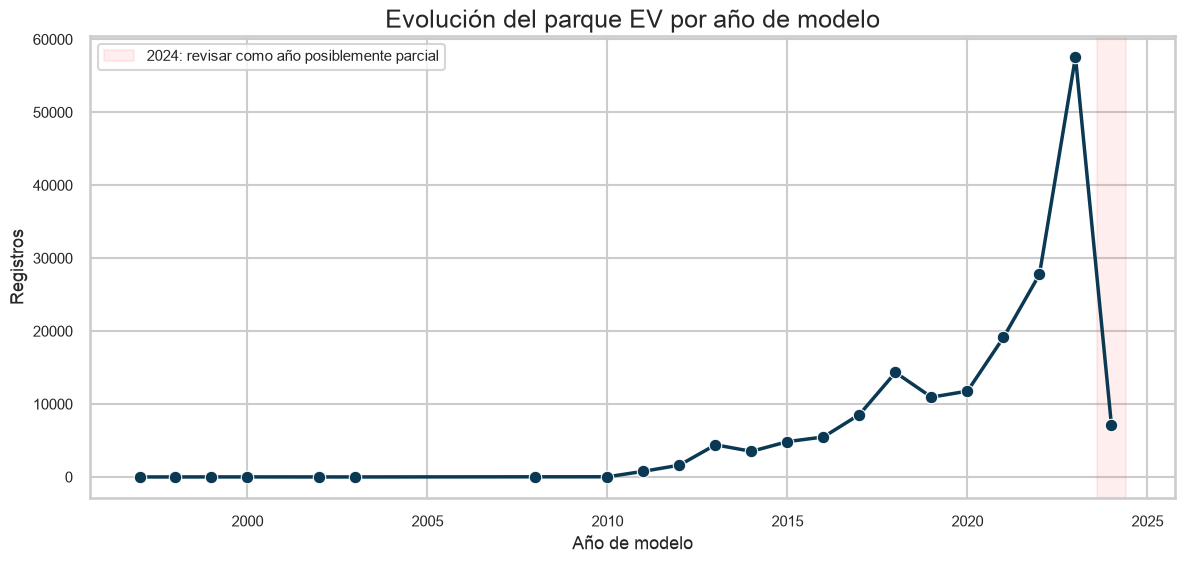

CAGR aproximado 2017-2023: 37.39%


In [11]:
market_kpis = {
    "registros_totales": int(len(df)),
    "anios_cubiertos": f"{int(df['model_year'].min())} - {int(df['model_year'].max())}",
    "estados_observados": int(df["state"].nunique()),
    "marcas_observadas": int(df["make"].nunique()),
    "modelos_observados": int(df["model"].nunique()),
    "share_washington_pct": round(df["state"].eq("WA").mean() * 100, 2),
    "share_bev_pct": round(df["is_bev"].mean() * 100, 2),
    "share_phev_pct": round(df["is_phev"].mean() * 100, 2),
}

kpi_df = pd.DataFrame(market_kpis.items(), columns=["indicador", "valor"])
display(kpi_df)

yearly_market = (
    df.groupby("model_year")
    .size()
    .reset_index(name="registrations")
    .sort_values("model_year")
)

cagr_base = yearly_market[yearly_market["model_year"].between(2017, 2023)]
cagr = ((cagr_base["registrations"].iloc[-1] / cagr_base["registrations"].iloc[0]) ** (1 / (len(cagr_base) - 1)) - 1)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=yearly_market, x="model_year", y="registrations", marker="o", linewidth=2.5, ax=ax)
ax.set_title("Evolución del parque EV por año de modelo")
ax.set_xlabel("Año de modelo")
ax.set_ylabel("Registros")
ax.axvspan(2024 - 0.4, 2024 + 0.4, color="#FF5A5F", alpha=0.10, label="2024: revisar como año posiblemente parcial")
ax.legend()
plt.show()

print(f"CAGR aproximado 2017-2023: {cagr:.2%}")


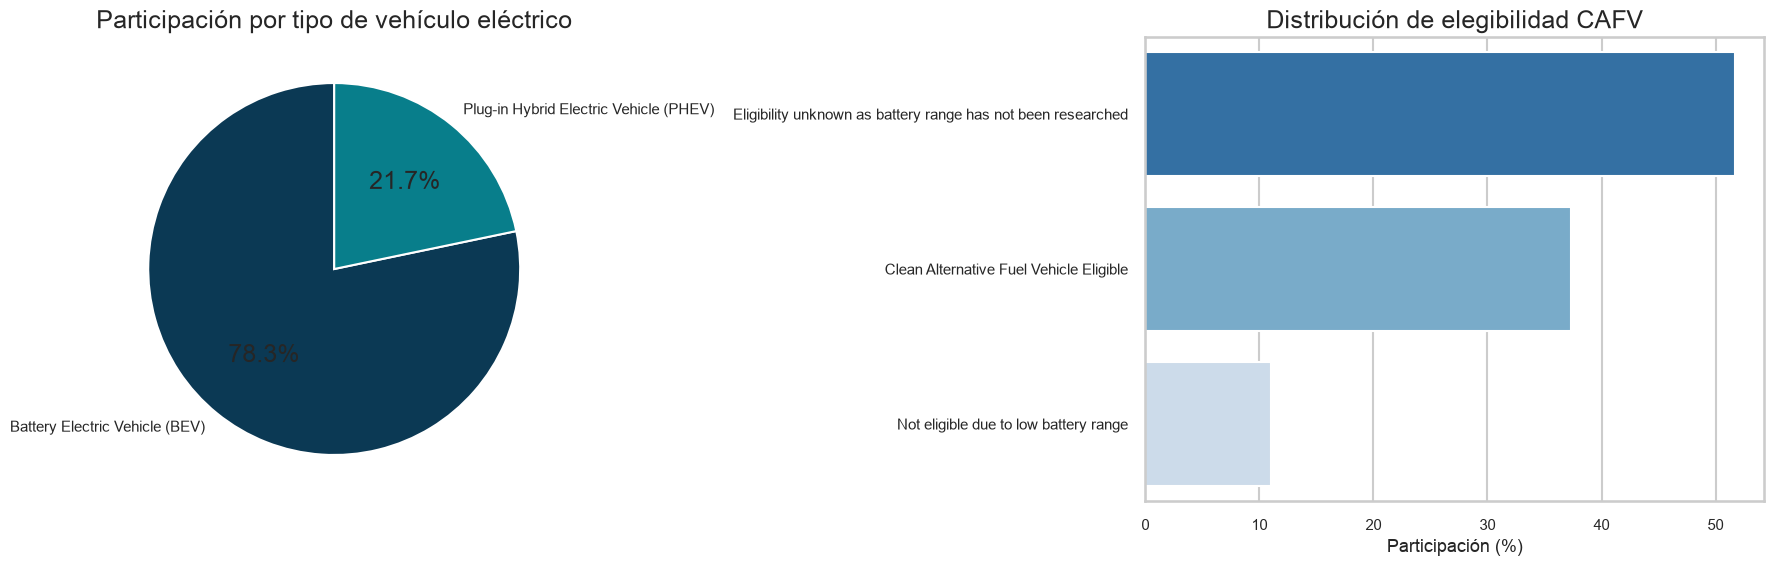

,ev_type,share_pct
0,Battery Electric Vehicle (BEV),78.27
1,Plug-in Hybrid Electric Vehicle (PHEV),21.73


,cafv_eligibility,share_pct
0,Eligibility unknown as battery range has not b...,51.7
1,Clean Alternative Fuel Vehicle Eligible,37.29
2,Not eligible due to low battery range,11.01


In [12]:
composition_type = (
    df["ev_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("ev_type")
    .reset_index(name="share_pct")
)

cafv_distribution = (
    df["cafv_eligibility"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("cafv_eligibility")
    .reset_index(name="share_pct")
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].pie(
    composition_type["share_pct"],
    labels=composition_type["ev_type"],
    autopct="%1.1f%%",
    startangle=90,
    colors=PALETTE[:2],
)
axes[0].set_title("Participación por tipo de vehículo eléctrico")

sns.barplot(data=cafv_distribution, y="cafv_eligibility", x="share_pct", ax=axes[1], palette="Blues_r")
axes[1].set_title("Distribución de elegibilidad CAFV")
axes[1].set_xlabel("Participación (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

display(composition_type)
display(cafv_distribution)


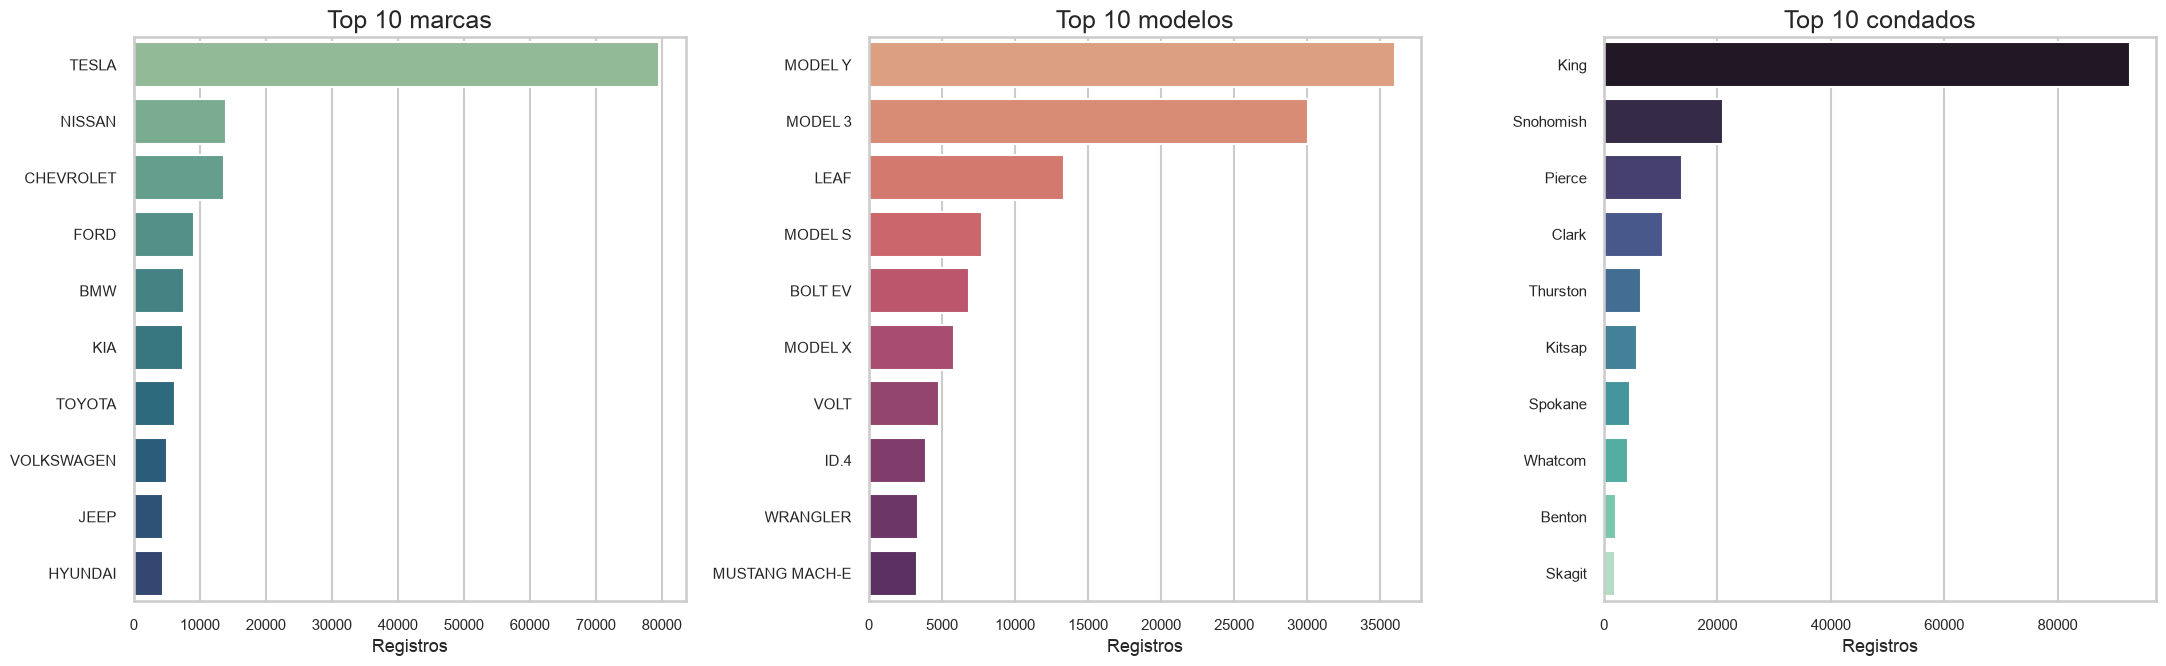

,make,registrations
0,TESLA,79659
1,NISSAN,13998
2,CHEVROLET,13678
3,FORD,9199
4,BMW,7570
5,KIA,7432
6,TOYOTA,6288
7,VOLKSWAGEN,5004
8,JEEP,4480
9,HYUNDAI,4406


,model,registrations
0,MODEL Y,35989
1,MODEL 3,30092
2,LEAF,13366
3,MODEL S,7735
4,BOLT EV,6821
5,MODEL X,5796
6,VOLT,4796
7,ID.4,3937
8,WRANGLER,3392
9,MUSTANG MACH-E,3322


,county,registrations
0,King,92740
1,Snohomish,21001
2,Pierce,13782
3,Clark,10416
4,Thurston,6428
5,Kitsap,5840
6,Spokane,4586
7,Whatcom,4253
8,Benton,2147
9,Skagit,1910


In [13]:
top_makes = (
    df["make"].value_counts().head(10)
    .rename_axis("make")
    .reset_index(name="registrations")
)
top_models = (
    df["model"].value_counts().head(10)
    .rename_axis("model")
    .reset_index(name="registrations")
)
top_counties = (
    df["county"].value_counts().head(10)
    .rename_axis("county")
    .reset_index(name="registrations")
)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

sns.barplot(data=top_makes, y="make", x="registrations", ax=axes[0], palette="crest")
axes[0].set_title("Top 10 marcas")
axes[0].set_xlabel("Registros")
axes[0].set_ylabel("")

sns.barplot(data=top_models, y="model", x="registrations", ax=axes[1], palette="flare")
axes[1].set_title("Top 10 modelos")
axes[1].set_xlabel("Registros")
axes[1].set_ylabel("")

sns.barplot(data=top_counties, y="county", x="registrations", ax=axes[2], palette="mako")
axes[2].set_title("Top 10 condados")
axes[2].set_xlabel("Registros")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

display(top_makes)
display(top_models)
display(top_counties)


## Segmentación territorial con clustering

Para complementar el análisis descriptivo, se construye una segmentación de condados usando variables de tamaño, mezcla de producto y diversidad de oferta. Esto ayuda a distinguir mercados maduros, mercados en expansión y mercados de menor tracción.


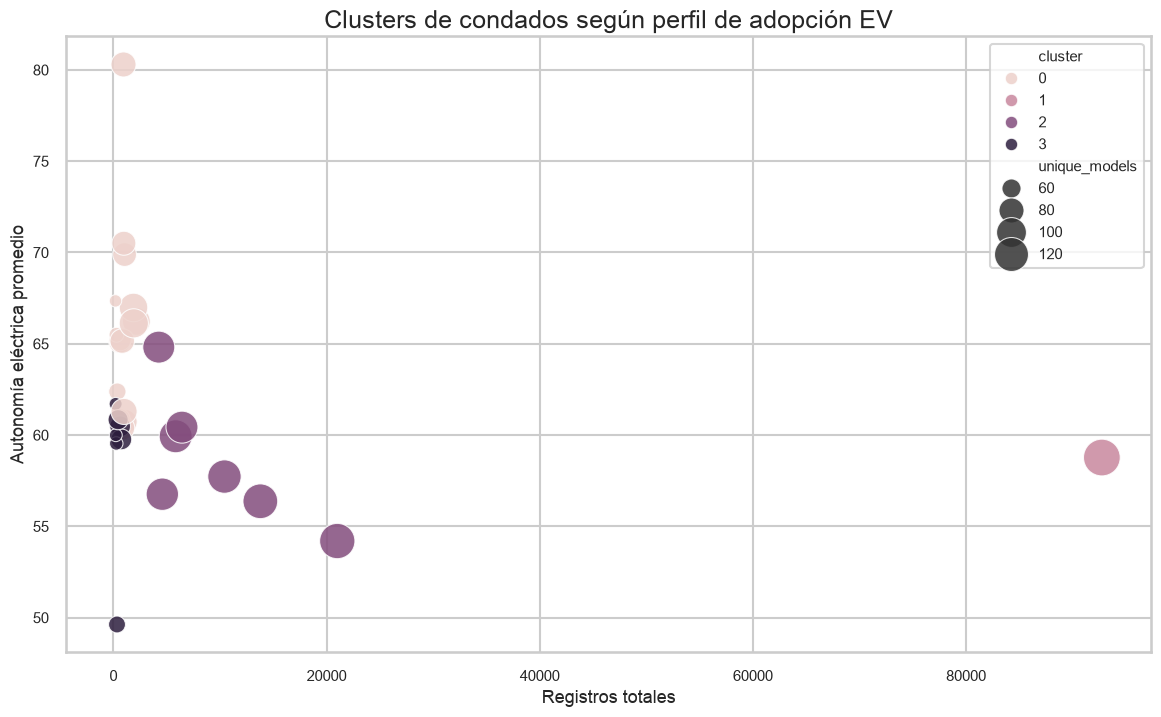

,county,total_registrations,bev_share,avg_electric_range,unique_makes,unique_models,cluster,share_of_market
11,King,92740,0.808087,58.769495,38,135,1,0.523499
23,Snohomish,21001,0.823485,54.196800,36,127,2,0.118547
19,Pierce,13782,0.760702,56.374619,34,124,2,0.077797
3,Clark,10416,0.738671,57.727823,34,117,2,0.058796
26,Thurston,6428,0.745333,60.433727,34,110,2,0.036285
12,Kitsap,5840,0.737329,59.934760,34,115,2,0.032966
24,Spokane,4586,0.683384,56.761666,34,112,2,0.025887
28,Whatcom,4253,0.745121,64.816600,35,110,2,0.024007
0,Benton,2147,0.693992,66.228225,28,91,0,0.012119
21,Skagit,1910,0.746073,66.120942,32,97,0,0.010782


,total_registrations,bev_share,avg_electric_range,unique_makes,unique_models
cluster,,,,,
1,92740.00,0.81,58.77,38.00,135.00
2,9472.29,0.75,58.61,34.43,116.43
0,955.56,0.73,65.87,27.44,73.75
3,402.71,0.64,58.85,23.86,54.71


In [14]:
county_kpis = (
    df.groupby("county")
    .agg(
        total_registrations=("dol_vehicle_id", "count"),
        bev_share=("is_bev", "mean"),
        avg_electric_range=("electric_range", "mean"),
        unique_makes=("make", "nunique"),
        unique_models=("model", "nunique"),
    )
    .dropna()
    .query("total_registrations >= 100")
    .reset_index()
)

features = ["total_registrations", "bev_share", "avg_electric_range", "unique_makes", "unique_models"]
model = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=4, random_state=42, n_init=10)
)
county_kpis["cluster"] = model.fit_predict(county_kpis[features])

cluster_profile = (
    county_kpis.groupby("cluster")[features]
    .mean()
    .round(2)
    .sort_values("total_registrations", ascending=False)
)

county_kpis["share_of_market"] = county_kpis["total_registrations"] / county_kpis["total_registrations"].sum()

fig, ax = plt.subplots(figsize=(14, 8))
scatter = sns.scatterplot(
    data=county_kpis,
    x="total_registrations",
    y="avg_electric_range",
    hue="cluster",
    size="unique_models",
    sizes=(80, 700),
    alpha=0.85,
    ax=ax,
)
ax.set_title("Clusters de condados según perfil de adopción EV")
ax.set_xlabel("Registros totales")
ax.set_ylabel("Autonomía eléctrica promedio")
plt.show()

display(county_kpis.sort_values("total_registrations", ascending=False).head(15))
display(cluster_profile)


## Pronóstico simple del tamaño de mercado

Como aproximación introductoria, se modela la evolución de registros por `Model Year` mediante una regresión polinómica de grado 2 entrenada sobre el periodo 2013-2023. Se excluye 2024 del entrenamiento para evitar sesgo por posible parcialidad del dato.


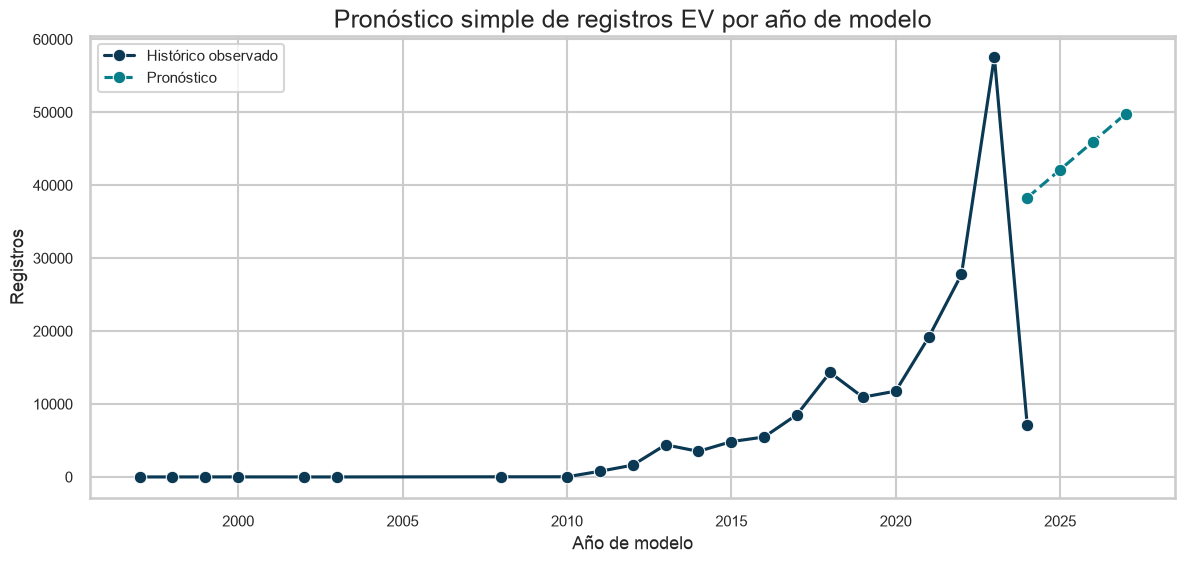

Predicción de corto plazo:


,model_year,forecast_registrations
0,2024,38288
1,2025,42127
2,2026,45968
3,2027,49811


Registro observado para 2024 en el dataset: 7,080


In [15]:
yearly_forecast_base = yearly_market.query("2013 <= model_year <= 2023").copy()
X_train = yearly_forecast_base[["model_year"]]
y_train = yearly_forecast_base["registrations"]

forecast_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)
forecast_model.fit(X_train, y_train)

future_years = pd.DataFrame({"model_year": [2024, 2025, 2026, 2027]})
future_years["forecast_registrations"] = np.maximum(
    forecast_model.predict(future_years[["model_year"]]),
    0
).round().astype(int)

plot_df = yearly_market.merge(
    future_years.rename(columns={"forecast_registrations": "forecast"}),
    on="model_year",
    how="outer"
).sort_values("model_year")

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=yearly_market, x="model_year", y="registrations", marker="o", label="Histórico observado", ax=ax)
sns.lineplot(data=future_years, x="model_year", y="forecast_registrations", marker="o", linestyle="--", label="Pronóstico", ax=ax)
ax.set_title("Pronóstico simple de registros EV por año de modelo")
ax.set_xlabel("Año de modelo")
ax.set_ylabel("Registros")
plt.show()

observed_2024 = yearly_market.loc[yearly_market["model_year"] == 2024, "registrations"]
observed_2024 = int(observed_2024.iloc[0]) if not observed_2024.empty else np.nan

print("Predicción de corto plazo:")
display(future_years)
print(f"Registro observado para 2024 en el dataset: {observed_2024:,}")


In [ ]:
top_make = top_makes.iloc[0]
top_model = top_models.iloc[0]
top_county = top_counties.iloc[0]

insights = f'''
### Hallazgos 

- El dataset contiene **{len(df):,} registros** entre los años modelo **{int(df['model_year'].min())} y {int(df['model_year'].max())}**.
- Washington concentra **{market_kpis['share_washington_pct']}%** del mercado observado, lo que confirma un alcance fuertemente regional.
- Los **BEV** dominan el mercado con **{market_kpis['share_bev_pct']}%**, por encima de los **PHEV**.
- La marca líder es **{top_make['make']}** con **{top_make['registrations']:,} registros**, y el modelo con mayor presencia es **{top_model['model']}**.
- El condado de **{top_county['county']}** concentra la mayor base instalada observada con **{top_county['registrations']:,} registros**.
- Entre 2017 y 2023, el crecimiento anual compuesto aproximado del mercado fue de **{cagr:.2%}**, señal de expansión acelerada.

### Recomendaciones estratégicas

- Priorizar estrategias comerciales y de infraestructura en los condados con mayor concentración y diversidad de modelos.
- Diseñar propuestas diferenciadas para mercados maduros frente a mercados emergentes usando la segmentación por clusters.
- Enfocar alianzas y campañas en el segmento **BEV**, que hoy representa la mayor masa crítica del mercado.
- Tratar cualquier lectura de 2024 como una señal preliminar y no como una caída estructural del mercado.
'''

display(Markdown(insights))



### Hallazgos clave

- El dataset contiene **177,866 registros** entre los años modelo **1997 y 2024**.
- Washington concentra **99.78%** del mercado observado, lo que confirma un alcance fuertemente regional.
- Los **BEV** dominan el mercado con **78.27%**, por encima de los **PHEV**.
- La marca líder es **TESLA** con **79,659 registros**, y el modelo con mayor presencia es **MODEL Y**.
- El condado de **King** concentra la mayor base instalada observada con **92,740 registros**.
- Entre 2017 y 2023, el crecimiento anual compuesto aproximado del mercado fue de **37.39%**, señal de expansión acelerada.

### Recomendaciones estratégicas

- Priorizar estrategias comerciales y de infraestructura en los condados con mayor concentración y diversidad de modelos.
- Diseñar propuestas diferenciadas para mercados maduros frente a mercados emergentes usando la segmentación por clusters.
- Enfocar alianzas y campañas en el segmento **BEV**, que hoy representa la mayor masa crítica del mercado.
- Tratar cualquier lectura de 2024 como una señal preliminar y no como una caída estructural del mercado.
